# Data Cleaning and Visualization On NYC Airbnb Open Data

In [71]:
# Importing pandas
import pandas as pd

# Importing matplotlib
import matplotlib.pyplot as plt

## Reading the File

In [72]:
# Making data frame from xlsx file
df = pd.read_excel("AB_NYC_2019.xlsx")

# print data frame
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaT,NaN,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaT,NaN,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaT,NaN,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaT,NaN,6,2


## Printing the First 5 rows of the file

In [73]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Looking for problems 

In [74]:
# Here we check the amount of null values in each of the columns

df.isnull().sum()

id                                    0
name                                 26
host_id                               0
host_name                            22
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

From the cell above we can see that there are no values missing for
like id, host id, neighbourhood group, neighbour, longitude, latitude
and so on as you can see. So we move on to the ones that have missing 
values like name, host name, last review and reviews per month

We can see that name and host name both have 26 and 22 missing values respectively.
But they arent that important for analysis of data so for those ones we can fill it
with "unknown" but for the ones like last review and review per month that have 
serious high amount of missing data up to over 10k like last review and reviews
per month we cant just leave them like that we have to do something about it,
so for reviews per month we fill them with "0's" meaning no reviews while 
for last review which is really important but has a lot of missing values 
we just drop it

## Cleaning Timeeee

In [75]:
# Here i'm just applying what i said about the missing values in the cell above

df['name'] = df['name'].fillna("Unknown")
df['host_name'] = df['host_name'].fillna("unknown")
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

df = df.drop(columns=['last_review'])

In [76]:
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2


So in the above cell something just happened😂. You can see that i printed 
df again its cos after i ran the previous code before this one, i forgot that 
i dropped the "last review" cell so it kept flagging error saying that 
theres nothing like that in the axis and i was confused why. But now from 
there you can see the result of what i did.

In [77]:
# Now lets check if there are still any null/missing values

df.isnull().sum()

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

There aren't which means we've cleared that up

## Cleaning Text

In [78]:
# Now we clean the text for the columns that contain text ensuring that all text
# are consistent instead of having some like "Manhattan", "manhattan ", 
# and "MANHATTAN"

df["neighbourhood_group"] = df["neighbourhood_group"].str.title()
df["room_type"] = df["room_type"].str.title()
df["name"] = df["name"].str.title()

In [79]:
# Now we print the first 5 again to check whether it worked and it did!!!
# As you can see after running this cell, The names are now in this format
# Mr. Pascal Is Teaching Us Data Cleaning With Pandas

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & Quiet Apt Home By The Park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private Room,149,1,9,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire Home/Apt,225,1,45,0.38,2,355
2,3647,The Village Of Harlem....New York !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private Room,150,3,0,0.00,1,365
3,3831,Cozy Entire Floor Of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire Home/Apt,89,1,270,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft By Central Park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire Home/Apt,80,10,9,0.10,1,0


In [80]:
# Here we check if there are any duplicate values
# There aren't but if there were we would have dropped them
df.duplicated().sum()


np.int64(0)

## Visualization: Visual 1

### Which type of listing is the most common?

<Axes: xlabel='room_type'>

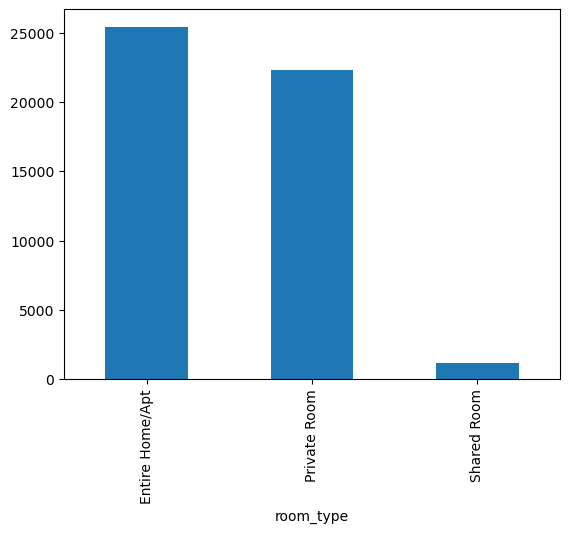

In [81]:
# Here we are checking the type of spaces people prefer to live in
# And we are showing it on a bar graph

df['room_type'].value_counts().plot(kind='bar')

### Insight

From the bar graph we can see that people prefer to live in entire homes/apartments 
more than private rooms or shared rooms which is the least with less than 5000
people

## Visual 2

### Where are most listings located?

<Axes: xlabel='neighbourhood_group'>

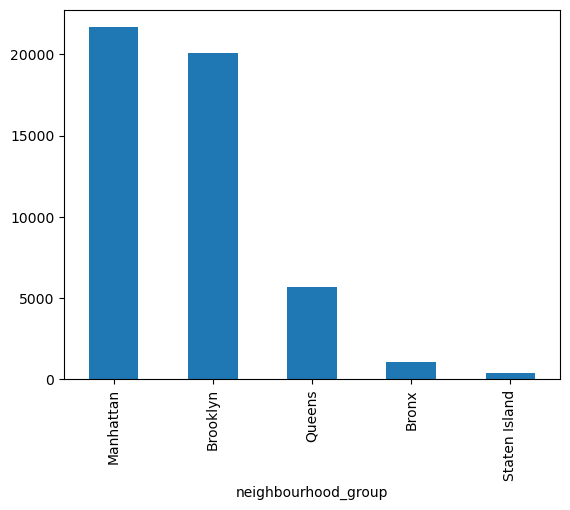

In [82]:
# Here we are checking the location of where the most space listings are located in

df['neighbourhood_group'].value_counts().plot(kind='bar')

### Insight

Clearly from the bar graph we can see that Manhattan dominates with more
than 20000 people and people likeairbnb's in manhattan more than in Brooklyn, 
Queens Bronx or staten Islandwhich has the lowest with less than 5000 people

## Visual 3

### How are prices spread?

<Axes: ylabel='Frequency'>

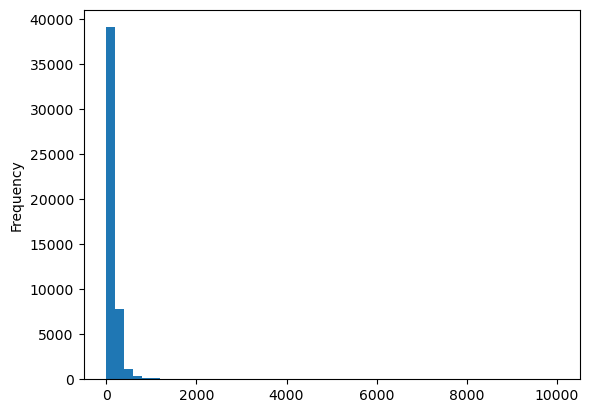

In [83]:
# Here we check how prices are spread, looking for the outliers

df['price'].plot(kind='hist', bins=50)

### Insight

We can see that most listings are cheap but few are extremely expensive; these
expensive ones are the outliers.